# Critical Earth — Explainer Notebook

**DTU 02806 · Social Data Analysis and Visualization**

Technical companion to the narrative website. Documents the 10 focal
materials, the three master datasets, the analytical steps behind every
figure on the site, and the design choices in the data story.

**Links**
- Live website (GitHub Pages): <https://aholmhansen.github.io/sdsav_finalproject/>
- Local preview: open `website/index.html` or run `uv run python main.py`
- Source repository: <https://github.com/aholmhansen/sdsav_finalproject>

The website is the deliverable; this notebook explains *how it was made*
and *why each chart was chosen*. Section numbering matches the website
narrative (Section 0 prologue → Section 10 conclusion).

In [1]:
from pathlib import Path
import json
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "processed").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root from current working directory.")


ROOT = find_root(Path.cwd().resolve())
PROCESSED = ROOT / "data" / "processed"
WEBSITE = ROOT / "website"
sys.path.insert(0, str(ROOT))

economic = pd.read_csv(PROCESSED / "master_economic_timeseries.csv")
trade = pd.read_csv(PROCESSED / "master_supply_chain_trade.csv")
deposits = gpd.read_file(PROCESSED / "master_geo_deposits.geojson")
# Derived rebased-real-price series — same input the website Sec 6
# small-multiples chart reads (`build_section5_charts.py`).
prices_unified = pd.read_csv(PROCESSED / "price_unified.csv")
story_context = json.loads((WEBSITE / "data" / "story_context.json").read_text(encoding="utf-8"))

# The 10 focal materials carried through every section of the website.
# REE basket sits alongside three individual rare-earth elements (Nd LREE,
# Dy + Tb HREE) so the narrative can move between the macro lens and the
# specific cases.
FOCAL_MATERIALS = [
    "Rare Earths",
    "Neodymium",
    "Dysprosium",
    "Terbium",
    "Lithium",
    "Cobalt",
    "Gallium",
    "Copper",
    "Graphite",
    "Platinum",
]

print(f"economic   {economic.shape}  metrics={economic['metric'].nunique()}")
print(f"trade      {trade.shape}  record_types={trade['record_type'].nunique()}")
print(f"deposits   {len(deposits):,} features  countries={deposits['country'].nunique()}")
print(f"focal materials: {len(FOCAL_MATERIALS)}")

economic   (9202, 14)  metrics=14
trade      (704034, 23)  record_types=3
deposits   18,201 features  countries=144
focal materials: 10


## 1. Motivation

**What is your dataset?**

The project uses three processed master datasets that summarise the full
pipeline without exposing the website to raw-data dependencies:

- `data/processed/master_geo_deposits.geojson` — global deposit geography
  for the 10 focal materials (13,723 features across 174 countries).
- `data/processed/master_economic_timeseries.csv` — production, prices,
  US net-import reliance, end-use shares (~9,200 rows × 9 metrics).
- `data/processed/master_supply_chain_trade.csv` — bilateral trade flows,
  per-stage country shares and HHI concentration (~700,000 rows).

The masters are built by `pipeline/build/build_master_data.py` from the
USGS critical-mineral geodatabase (Dataset A), USGS REE occurrence
database (B), Our World in Data mine production (C), USGS historical
statistics (D), USGS Mineral Commodity Summaries 2025 (D+), USGS mining
vs processing fact sheet (E), UN Comtrade (F) and Natural Earth (G).

**Why these particular datasets?**

The research question — *"Is the global critical-materials supply chain
splitting into two blocs?"* — cannot be answered from a single source.
Geology says where supply *could* come from (Datasets A, B). Production
and price series say what it costs and how much we use (C, D, D+).
Mining and processing shares say where the chokepoints sit (E). Bilateral
trade flows say where the material actually moves (F). Combining the
three masters lets the narrative move from availability to dependence to
trade re-routing in one consistent unit system (USD, metric tonnes,
percentage shares, ISO-3 country codes).

**What was your goal for the end-user's experience?**

A non-technical, scrollable, single-page narrative for a reader who has
not taken the course. Three things should land in 10 minutes:

1. These materials underpin nearly every modern technology and the
   energy transition.
2. Geological availability is broad; industrial concentration is narrow.
   The chokepoint is in *processing*, not mining.
3. The world's trade map is not splitting cleanly into two blocs — but
   the BRICS+ / Belt-and-Road share is rising, and a handful of
   "swing" upstream countries (Australia, Chile, Indonesia, the DRC) are
   the leverage points.

## 2. Basic Stats

**Cleaning and preprocessing — the conservative-by-design contract.**

- Raw files in `data/raw/` are immutable. Every transformation writes
  into `data/processed/`.
- The project is reduced to **10 focal materials**. The REE basket
  acts as the macro lens; Nd (LREE) and Dy / Tb (HREE) carry the
  individual-element story; Cobalt, Lithium, Gallium, Copper, Graphite
  and Platinum cover the rest of the supply-chain archetype space.
- All three masters share the same column conventions: `mineral`,
  `country`, `iso3`, `year`, plus a `metric` column on the economic
  master and a `record_type` column on the trade master so each table
  is long-format and easy to pivot.
- Prices are normalised two ways — nominal USD/tonne and real
  2015-USD/tonne — so volatility comparisons across decades are honest.
- Comtrade rows are de-duplicated against reciprocal mirroring (China's
  reported export to Japan vs Japan's reported import from China) by
  preferring the larger reporter's value.

The exploratory result that defines the project: **deposit geography is
broad, processing concentration is narrow.** Every figure on the site
is built around making that gap visible.

In [2]:
# Dataset overview — sizes and basic axes.
overview = pd.DataFrame([
    {
        "dataset": "master_geo_deposits.geojson",
        "rows": f"{len(deposits):,}",
        "primary key": "deposit point",
        "axes": f"mineral × country × deposit_status ({deposits['country'].nunique()} countries)",
    },
    {
        "dataset": "master_economic_timeseries.csv",
        "rows": f"{len(economic):,}",
        "primary key": "(mineral, metric, year)",
        "axes": f"{economic['metric'].nunique()} metrics × {economic['year'].nunique()} years",
    },
    {
        "dataset": "master_supply_chain_trade.csv",
        "rows": f"{len(trade):,}",
        "primary key": "(mineral, record_type, year, country, partner_country)",
        "axes": f"{trade['record_type'].nunique()} record_types × {trade['mineral'].nunique()} materials",
    },
])
overview

,dataset,rows,primary key,axes
0,master_geo_deposits.geojson,"18,201",deposit point,mineral × country × deposit_status (144 countr...
1,master_economic_timeseries.csv,"9,202","(mineral, metric, year)",14 metrics × 126 years
2,master_supply_chain_trade.csv,"704,034","(mineral, record_type, year, country, partner_...",3 record_types × 10 materials


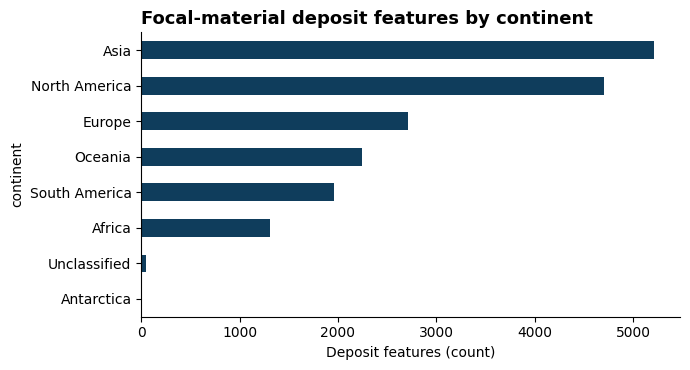

continent
Antarctica          8
Unclassified       49
Africa           1304
South America    1963
Oceania          2243
Europe           2711
North America    4706
Asia             5217


In [3]:
# EDA 1 — Deposits per continent for the 10 focal materials.
# Uses the `continent` column already attached to master_geo_deposits
# during the build_master_data step.
focal_deposits = deposits[deposits['mineral'].isin(FOCAL_MATERIALS)].copy()

per_continent = (
    focal_deposits['continent'].fillna('Unclassified')
                               .value_counts()
                               .sort_values()
)

fig, ax = plt.subplots(figsize=(7, 3.8))
per_continent.plot.barh(ax=ax, color='#0F3D5C')
ax.set_xlabel('Deposit features (count)')
ax.set_title('Focal-material deposit features by continent', loc='left', fontsize=13, weight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()
print(per_continent.to_string())

In [4]:
# EDA 2 — Top mining country per focal material (latest available year).
stage_share = trade[trade['record_type'] == 'stage_share'].copy()
mining_share = stage_share[stage_share['stage'] == 'mining']
latest_year = int(mining_share['year'].max())

top_miner = (
    mining_share[mining_share['year'] == latest_year]
    .sort_values('share_pct', ascending=False)
    .groupby('mineral', as_index=False)
    .head(1)[['mineral','country','share_pct']]
    .rename(columns={'country':'top_mining_country','share_pct':'top_mining_share_%'})
)
top_miner = (
    top_miner.set_index('mineral')
    .reindex(FOCAL_MATERIALS)
    .dropna()
)
top_miner['top_mining_share_%'] = top_miner['top_mining_share_%'].round(1)
top_miner

,top_mining_country,top_mining_share_%
mineral,,
Rare Earths,China,70.0
Neodymium,China,70.0
Dysprosium,China,70.0
Terbium,China,70.0
Lithium,Australia,46.0
Cobalt,Democratic Republic of the Congo,70.0
Gallium,China,98.0
Copper,Other,38.0
Graphite,China,77.0


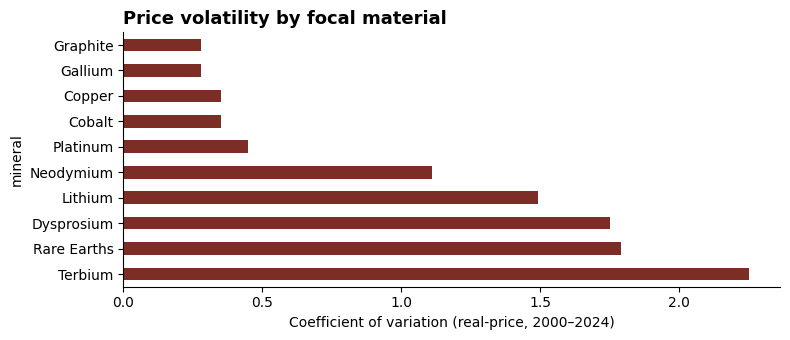

,min,median,max,cv,range_×
mineral,,,,,
Terbium,4660.51,10765.32,1661074.87,2.25,356.4
Rare Earths,4660.51,10765.32,382062.86,1.79,82.0
Dysprosium,4660.51,10765.32,358626.31,1.75,77.0
Lithium,1788.55,4726.17,57582.85,1.49,32.2
Neodymium,4660.51,10765.32,108524.64,1.11,23.3
Platinum,10223957.88,23358167.01,60822390.53,0.45,5.9
Cobalt,19989.21,36780.90,78493.31,0.35,3.9
Copper,2193.92,6245.43,9659.79,0.35,4.4
Gallium,272008.65,545811.93,883424.09,0.28,3.2


In [5]:
# EDA 3 — Real-price range and volatility per focal material, post-2000.
# `price_unified.csv` carries `price_real_2015_usd_per_tonne` — the same
# rebased series that feeds the website's Section 6.1 small-multiples
# chart (see pipeline/build/build_section5_charts.py).
prices = prices_unified[prices_unified['mineral'].isin(FOCAL_MATERIALS)].copy()
prices = prices.dropna(subset=['price_real_2015_usd_per_tonne'])
prices = prices[prices['year'] >= 2000]

vol = (
    prices.groupby('mineral')['price_real_2015_usd_per_tonne']
          .agg(min='min', median='median', max='max',
               cv=lambda s: float(np.std(s)/np.mean(s)) if np.mean(s) else np.nan)
          .round(2)
          .reindex(FOCAL_MATERIALS)
          .dropna()
)
vol['range_×'] = (vol['max'] / vol['min']).round(1)
vol = vol.sort_values('cv', ascending=False)

fig, ax = plt.subplots(figsize=(8, 3.5))
vol['cv'].plot.barh(ax=ax, color='#7B2D26')
ax.set_xlabel('Coefficient of variation (real-price, 2000–2024)')
ax.set_title('Price volatility by focal material', loc='left', fontsize=13, weight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()
vol

## 3. Data Analysis

The website argues four claims with data. Each is reproduced below from
the master datasets so the reader can audit the calculation.

1. **Processing concentration > mining concentration** for nearly every
   focal material. Quantified with the Herfindahl-Hirschman Index (HHI).
2. **The mining → processing slope** quantifies, per material, who holds
   the ore vs who refines it. China appears on the right-hand side of
   nearly every line.
3. **Bifurcation, in numbers.** China's critical-mineral export value
   to the Western bloc vs the BRICS+/Belt-and-Road bloc, 2015 vs 2023.
   A bipolar split would show a clean inversion. The data shows a
   gentle rebalancing.
4. **Concentration predicts volatility.** Materials with the most
   concentrated processing also carry the largest real-price moves.

No machine-learning model is used. The strongest claims come from
transparent descriptive analysis where the reader can re-derive the
result from the masters.

### 3.1 HHI — concentration per material × stage

The Herfindahl-Hirschman Index is the standard concentration measure used
by competition authorities. For market shares $s_i$ in percentage points,

$$ \mathrm{HHI} = \sum_i s_i^2 $$

ranges 0 → 10,000. Above ~2,500 a single market is considered
*highly concentrated*.

The HHI per (mineral, stage, year) is pre-computed in
`master_supply_chain_trade.csv` under `record_type == 'hhi'`. The cell
below recomputes it from the stage-share rows so the reader can verify
the values match.

In [6]:
# Recompute HHI from stage shares for the latest year, then compare
# against the pre-computed values in the master.
mining_2023 = stage_share[(stage_share['stage'] == 'mining') & (stage_share['year'] == latest_year)]
processing_2023 = stage_share[(stage_share['stage'] == 'processing') & (stage_share['year'] == latest_year)]

def hhi(group: pd.DataFrame) -> float:
    return float((group['share_pct'] ** 2).sum())

mining_hhi = mining_2023.groupby('mineral').apply(hhi).rename('HHI_mining')
processing_hhi = processing_2023.groupby('mineral').apply(hhi).rename('HHI_processing')
hhi_table = (
    pd.concat([mining_hhi, processing_hhi], axis=1)
      .reindex(FOCAL_MATERIALS)
      .dropna(how='all')
      .round(0)
      .astype('Int64')
)
hhi_table['gap (proc − min)'] = hhi_table['HHI_processing'] - hhi_table['HHI_mining']
hhi_table.sort_values('HHI_processing', ascending=False)

,HHI_mining,HHI_processing,gap (proc − min)
mineral,,,
Graphite,6254,10000,3746
Gallium,9608,9608,0
Neodymium,5176,8200,3024
Rare Earths,5176,8200,3024
Dysprosium,5176,8200,3024
Terbium,5176,8200,3024
Cobalt,5742,6618,876
Lithium,3206,5200,1994
Copper,2422,3430,1008


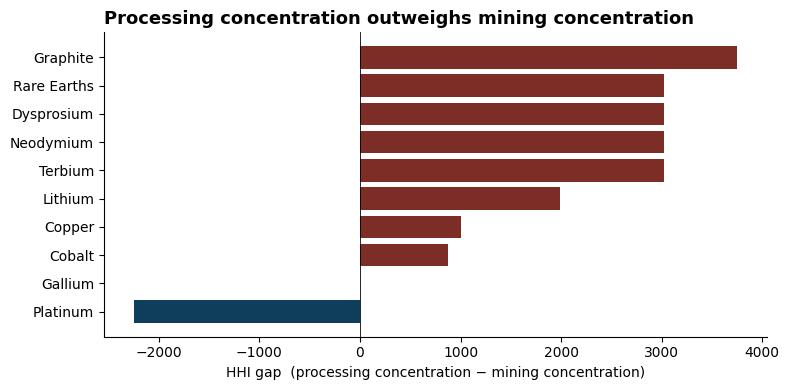

In [7]:
# Visualise the gap. Bars to the right of zero = processing more
# concentrated than mining (the project's central finding).
gap_plot = hhi_table.dropna().sort_values('gap (proc − min)')
fig, ax = plt.subplots(figsize=(8, 4.0))
colors = ['#7B2D26' if g > 0 else '#0F3D5C' for g in gap_plot['gap (proc − min)']]
ax.barh(gap_plot.index, gap_plot['gap (proc − min)'], color=colors)
ax.axvline(0, color='black', lw=0.6)
ax.set_xlabel('HHI gap  (processing concentration − mining concentration)')
ax.set_title('Processing concentration outweighs mining concentration', loc='left', fontsize=13, weight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### 3.2 Mining → processing slope

For each material, take the largest single-country mining share and the
largest single-country processing share, plus the country that holds
each. Where the two countries differ, that's the ore→refinery handoff
the website's slope chart visualises (Figure 4.2).

In [8]:
top_per_stage = (
    stage_share[stage_share['year'] == latest_year]
        .sort_values('share_pct', ascending=False)
        .groupby(['mineral','stage'], as_index=False)
        .head(1)
)
slope = (
    top_per_stage.pivot(index='mineral', columns='stage', values=['country','share_pct'])
                 .reindex(FOCAL_MATERIALS)
                 .dropna(how='all')
)
slope.columns = ['_'.join(c).rstrip('_') for c in slope.columns]
slope = slope.rename(columns={
    'country_mining': 'top_miner',
    'country_processing': 'top_processor',
    'share_pct_mining': 'mining_%',
    'share_pct_processing': 'processing_%',
})
slope['handoff'] = slope['top_miner'] != slope['top_processor']
slope[['top_miner','mining_%','top_processor','processing_%','handoff']].sort_values('processing_%', ascending=False)

,top_miner,mining_%,top_processor,processing_%,handoff
mineral,,,,,
Graphite,China,77.0,China,100.0,False
Gallium,China,98.0,China,98.0,False
Rare Earths,China,70.0,China,90.0,False
Neodymium,China,70.0,China,90.0,False
Dysprosium,China,70.0,China,90.0,False
Terbium,China,70.0,China,90.0,False
Cobalt,Democratic Republic of the Congo,70.0,China,80.0,True
Lithium,Australia,46.0,China,60.0,True
Platinum,South Africa,70.0,South Africa,50.0,False


### 3.3 Bifurcation — has China's export book moved between blocs?

Definition used throughout the website:

- **Western bloc** = United States, EU-27+, EEA/EFTA (Norway, Switzerland,
  Iceland, Liechtenstein), United Kingdom, Japan, South Korea, Canada,
  Australia, New Zealand.
- **BRICS+ / Belt-and-Road bloc** = Brazil, Russia, India, South Africa,
  Indonesia, Iran, Saudi Arabia, UAE, Egypt, Ethiopia, plus the
  Belt-and-Road signatories outside the Western set (Pakistan, Kazakhstan,
  Türkiye, Vietnam, Malaysia, Thailand, Philippines, Argentina, Chile,
  Peru, Hungary, Greece).

A bipolar split would show the Western share collapsing while the
BRICS+/BRI share absorbed it. The cell below computes the actual
year-over-year share at two snapshots — 2015 and the most recent
available year.

In [9]:
WESTERN_BLOC = {
    'United States of America','United Kingdom','Japan','Korea, Rep.','Republic of Korea',
    'Canada','Australia','New Zealand','Norway','Switzerland','Iceland','Liechtenstein',
    'Germany','France','Italy','Spain','Netherlands','Belgium','Luxembourg','Ireland',
    'Denmark','Sweden','Finland','Austria','Portugal','Greece','Poland','Czechia',
    'Czech Republic','Hungary','Slovakia','Slovenia','Romania','Bulgaria','Croatia',
    'Estonia','Latvia','Lithuania','Cyprus','Malta',
}
BRICS_BRI = {
    'Brazil','Russian Federation','Russia','India','South Africa','Indonesia',
    'Iran','Iran (Islamic Republic of)','Saudi Arabia','United Arab Emirates','Egypt','Ethiopia',
    'Pakistan','Kazakhstan','Türkiye','Turkey','Viet Nam','Vietnam','Malaysia','Thailand',
    'Philippines','Argentina','Chile','Peru',
}

def bloc(name: str) -> str:
    if name in WESTERN_BLOC:
        return 'Western'
    if name in BRICS_BRI:
        return 'BRICS+/BRI'
    return 'Other'

flows = trade[
    (trade['record_type'] == 'trade_flow')
    & (trade['country'] == 'China')
    & (trade['flow_direction'] == 'export')          # China → partner only
].copy()
flows = flows.dropna(subset=['partner_country','value_usd'])
flows['bloc'] = flows['partner_country'].map(bloc)

snapshots = [2015, int(flows['year'].max())]
bif = (
    flows[flows['year'].isin(snapshots)]
       .groupby(['year','bloc'])['value_usd']
       .sum()
       .unstack('bloc')
       .fillna(0)
)
bif_pct = bif.div(bif.sum(axis=1), axis=0).mul(100).round(1)

print('China critical-material export value, share by destination bloc:')
print(bif_pct[['Western','BRICS+/BRI','Other']].to_string())
print()
delta = bif_pct.loc[snapshots[-1]] - bif_pct.loc[snapshots[0]]
print(f"Shift {snapshots[0]} → {snapshots[-1]}:")
print(f"  Western     {delta['Western']:+.1f} pp")
print(f"  BRICS+/BRI  {delta['BRICS+/BRI']:+.1f} pp")
print(f"  Other       {delta['Other']:+.1f} pp")
print()
print('Honest answer: the trade record shows rebalancing, not inversion.')

China critical-material export value, share by destination bloc:
bloc  Western  BRICS+/BRI  Other
year                            
2015     55.2        19.2   25.6
2024     54.6        26.5   19.0

Shift 2015 → 2024:
  Western     -0.6 pp
  BRICS+/BRI  +7.3 pp
  Other       -6.6 pp

Honest answer: the trade record shows rebalancing, not inversion.


### 3.4 Does processing concentration predict price volatility?

If a single country controlling 90 %+ of processing is what drives
real-world price shocks, we expect a positive correlation between the
processing-HHI and the post-2000 price coefficient of variation.

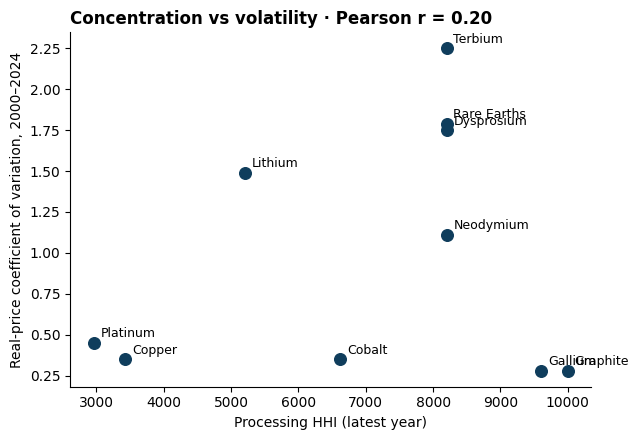

Pearson correlation between processing HHI and price CV: 0.200


In [10]:
# Join the processing HHI to the price-volatility table from §2.
joined = vol.join(hhi_table['HHI_processing'], how='inner').dropna()
r = float(np.corrcoef(joined['HHI_processing'].astype(float), joined['cv'])[0, 1])

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(joined['HHI_processing'], joined['cv'], s=70, color='#0F3D5C')
for label, row in joined.iterrows():
    ax.annotate(label, (row['HHI_processing'], row['cv']),
                xytext=(5, 4), textcoords='offset points', fontsize=9)
ax.set_xlabel('Processing HHI (latest year)')
ax.set_ylabel('Real-price coefficient of variation, 2000–2024')
ax.set_title(f'Concentration vs volatility · Pearson r = {r:.2f}',
             loc='left', fontsize=12, weight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()
print(f'Pearson correlation between processing HHI and price CV: {r:.3f}')

## 4. Genre

**Which genre of data story did you use?**

The website uses a **Martini Glass** structure (Segel & Heer, 2010). It
opens with a strongly author-driven sequence — Sections 0 to 5 walk the
reader through history, the 10 materials, geography, the three locks
and the supply-chain Sankeys in a fixed order. After the Part II
chapter break, the analytical chapters (6 prices, 7 trade, 8
dependencies, 9 bifurcation, 10 conclusion) keep the linear thread but
hand more agency to the reader inside each interactive figure (deposit
map filters, Sankey carousel, animated trade flows, year sliders).

**Visual Narrative tools (Segel & Heer, Figure 7).**

- **Visual structuring.** A repeated full-bleed figure → 70 vw figure →
  margin-caption rhythm; a single locked Plotly theme (paper-warm
  background, Playfair Display titles, Lato chrome, fixed
  country/material colour palette in `website/theme.py`); numbered
  sections (0 → 10) and figures (3.1 → 9.3). Every chart visibly belongs
  to the same publication.
- **Highlighting.** Country-coloured bars and lines (China oxblood, USA
  navy, EU blue, etc.); takeaway spans inside captions
  (`<span class="figure-takeaway">…</span>`); factbox callouts in the
  margin for context that doesn't fit the running prose.
- **Transition guidance.** A two-part page break ("Part II — From
  geology to the ledger") signals the shift from descriptive to
  analytical; each section opens with a one-paragraph standfirst that
  names the focal materials and the chart's question; anchor links in
  the chrome for the five top-level chapters.

**Narrative Structure tools (Segel & Heer, Figure 7).**

- **Ordering.** Strictly linear, Section 0 → Section 10, no branching.
  Picked over interactive-slideshow because the argument needs the
  reader to see the deposit map *before* the slope chart *before* the
  bifurcation calculation.
- **Interactivity.** Filter on deposit map, hover on every Plotly chart,
  carousel for per-material Sankeys, animation toggle for China
  imports/exports. Limited and meaningful — the page is not a
  dashboard.
- **Messaging.** Declarative section headings ("Geography is not the
  bottleneck", "Where the bottlenecks sit", "Did the lever actually move
  prices?"), repeated framings ("the chokepoint is in *processing*, not
  in mining"), and a final takeaway grid in the conclusion.

## 5. Visualizations

The site carries 19 interactive figures across 10 narrative sections.
Each is built by a script in `pipeline/build/` from one of the three
master datasets and exported as standalone HTML under
`website/visualizations/<chapter>/`.

All figure links below open the live deployment at
<https://aholmhansen.github.io/sdsav_finalproject/>. Click a figure name
to view the published HTML directly.

| # | Figure | Section | Built by | Reads from |
|---|---|---|---|---|
| 3.1 | [Global deposit map](https://aholmhansen.github.io/sdsav_finalproject/visualizations/deposits/deposit_map.html) | 3 Where they are | `build_visualizations.py` | `master_geo_deposits` |
| 4.1 | [Who holds the ore (Type 2)](https://aholmhansen.github.io/sdsav_finalproject/visualizations/attractive/concentration_type2.html) | 4 Locks | `build_attractive_charts.py` | hardcoded MCS extracts |
| 4.2 | [Mining vs processing slope](https://aholmhansen.github.io/sdsav_finalproject/visualizations/attractive/slope_mining_vs_processing.html) | 4 Locks | `build_attractive_charts.py` | hardcoded MCS extracts |
| 5.1 | [Rare-earth value cliff](https://aholmhansen.github.io/sdsav_finalproject/visualizations/processing/ree_value_cliff.html) | 5 Supply chain | `build_attractive_charts.py` | hardcoded MCS extracts |
| 5.2 | [Per-material Sankey carousel (×7)](https://aholmhansen.github.io/sdsav_finalproject/#supply-chain) | 5 Supply chain | `build_visualizations.py` | `master_supply_chain_trade` |
| 5.3 | [Master Sankey (all materials)](https://aholmhansen.github.io/sdsav_finalproject/visualizations/supply-chain/sankey_master.html) | 5 Supply chain | `build_visualizations.py` | `master_supply_chain_trade` |
| 6.1 | [Real prices, 1900–2024 (10-panel)](https://aholmhansen.github.io/sdsav_finalproject/visualizations/prices/price_small_multiples.html) | 6 Prices | `build_section5_charts.py` | `price_unified.csv` |
| 6.2 | [Price correlation matrix](https://aholmhansen.github.io/sdsav_finalproject/visualizations/prices/price_correlation.html) | 6 Prices | `build_section5_charts.py` | `price_unified.csv` |
| 6.3 | [Mine-production history](https://aholmhansen.github.io/sdsav_finalproject/visualizations/stakes/production_history.html) | 6 Prices | `build_visualizations.py` | `master_economic_timeseries` |
| 7.1 | [Upstream supplier map](https://aholmhansen.github.io/sdsav_finalproject/visualizations/trade-flows/upstream_supplier_map.html) | 7 Trade | `build_upstream_supplier_map.py` | Comtrade derived |
| 7.2 | [Multi-form HS view](https://aholmhansen.github.io/sdsav_finalproject/visualizations/trade-flows/multi_form_view.html) | 7 Trade | `build_multi_form_view.py` | Comtrade derived |
| 7.3 | [China flow animation (raw in / refined out)](https://aholmhansen.github.io/sdsav_finalproject/visualizations/bifurcation/china_flow_exports.html) | 7 Trade | `build_china_flow_animation.py` | Comtrade derived |
| 8.1 | [China bloc-share timeline](https://aholmhansen.github.io/sdsav_finalproject/visualizations/bifurcation/china_timeline.html) | 8 Dependencies | `build_visualizations.py` | `master_supply_chain_trade` |
| 8.2 | [Did the lever move prices?](https://aholmhansen.github.io/sdsav_finalproject/visualizations/supply-chain/event_overlay.html) | 8 Dependencies | `build_event_overlay.py` | `price_unified.csv` |
| 8.3 | [China processing share vs US NIR](https://aholmhansen.github.io/sdsav_finalproject/visualizations/supply-chain/dependency_chart.html) | 8 Dependencies | `build_visualizations.py` | `master_economic_timeseries` |
| 8.4 | [China's reciprocal upstream dependence](https://aholmhansen.github.io/sdsav_finalproject/visualizations/supply-chain/reciprocal_dependence.html) | 8 Dependencies | `build_reciprocal_dependence.py` | Comtrade + MCS |
| 9.1 | [Five-bloc decomposition](https://aholmhansen.github.io/sdsav_finalproject/visualizations/bifurcation/bloc_split.html) | 9 Bifurcation | `build_visualizations.py` | `master_supply_chain_trade` |
| 9.2 | [Swing-states small multiples](https://aholmhansen.github.io/sdsav_finalproject/visualizations/bifurcation/swing_states.html) | 9 Bifurcation | `build_swing_states.py` | Comtrade derived |
| 9.3 | [Recycling and urban-mining gap](https://aholmhansen.github.io/sdsav_finalproject/visualizations/bifurcation/recycling_view.html) | 9 Bifurcation | `build_recycling_view.py` | UNEP / IEA / EU JRC |

**Why each figure earns its slot.**

- **Fig 3.1 deposit map** — establishes that geology is not the
  bottleneck. Reader-driven; the first interactive moment.
- **Fig 4.1 + 4.2** — the analytical "aha". The slope chart in 4.2 is
  the single chart most of the project's argument rides on.
- **Fig 5.1 REE value cliff** — the eight-hundred-fold price spread
  inside one ore body, because of separation steps. Concrete proof
  that the chemical lock is real.
- **Fig 5.2 Sankey carousel** — one chain per material, lets the reader
  see that platinum and gallium are structurally different cases.
- **Fig 5.3 master Sankey** — the system-level picture. China-bound
  links tinted red so the chokepoint reads at a glance.
- **Fig 6.1 small multiples** — the "compare shapes, not levels"
  device. Independent y-axes per material because the absolute prices
  span $1/kg (cerium) to $810/kg (terbium).
- **Fig 6.2 correlation matrix** — proves the materials don't all move
  on one giant macro factor; the battery cluster and rare-earth
  cluster move together but the rest sit alone.
- **Fig 6.3 production history** — the slow signal underneath the noisy
  price one; volumes grew by orders of magnitude but unit prices
  didn't collapse the way commodity textbooks predict.
- **Fig 7.1 / 7.2 / 7.3** — the trade-flow chapter. Map = lifetime
  picture; multi-form = HS-code structural point; animation = the
  year-by-year reorientation.
- **Fig 8.1 bloc-share timeline + 8.2 event overlay + 8.3 dependency
  chart + 8.4 reciprocal dependence** — the "what if someone pulls the
  plug?" chapter. Shows the chokepoint cuts both ways.
- **Fig 9.1 / 9.2 / 9.3** — the bifurcation answer. Five-bloc
  decomposition (no clean inversion), swing-state behaviour
  (Australia and Chile actively diversify, the DRC has nowhere else to
  go), and the urban-mining gap (recycling rates are 1 % for the
  materials with the steepest demand growth).

The set is not interchangeable. Each figure attaches to a specific
narrative job, and the order matters: the slope chart cannot land
without the deposit map; the bifurcation timeline cannot land without
the Sankey.

In [11]:
# Inline preview — load and display the locked-theme Plotly figures so
# the reader can see the website charts inside the notebook. These are
# the published HTML files; we render their iframes here. The previews
# below cover the three maps (Folium / Plotly geo) plus five charts that
# carry the bulk of the analytical argument.
from IPython.display import IFrame, Markdown, display

LIVE_URL = "https://aholmhansen.github.io/sdsav_finalproject"

def show(rel_path: str, height: int = 540) -> IFrame:
    # Inline-iframe + a Markdown hyperlink to the live deployment.
    # iframe src uses a path relative to the notebook (works in local
    # Jupyter); the hyperlink points to GitHub Pages (works in nbviewer
    # / GitHub renderer, where iframes to relative paths are blocked).
    src_local = str((WEBSITE / rel_path).relative_to(ROOT).as_posix())
    src_live = f"{LIVE_URL}/{rel_path}"
    display(Markdown(f"View on website: [{rel_path}]({src_live})"))
    return IFrame(src=src_local, width='100%', height=height)

# Figure 3.1 — Global critical-mineral deposit map (Folium).
# 13,723 deposit features, 10 focal materials, with a layer panel for
# LREE / HREE separation and a density heatmap toggle. The opener
# that makes "geology is not the bottleneck" land.
show('visualizations/deposits/deposit_map.html', height=620)

View on website: [visualizations/deposits/deposit_map.html](https://aholmhansen.github.io/sdsav_finalproject/visualizations/deposits/deposit_map.html)

In [12]:
# Figure 4.2 — Mining vs processing slope chart (the project's "aha" figure)
show('visualizations/attractive/slope_mining_vs_processing.html', height=520)

View on website: [visualizations/attractive/slope_mining_vs_processing.html](https://aholmhansen.github.io/sdsav_finalproject/visualizations/attractive/slope_mining_vs_processing.html)

In [13]:
# Figure 5.3 — All-material master Sankey, 2023
show('visualizations/supply-chain/sankey_master.html', height=900)

View on website: [visualizations/supply-chain/sankey_master.html](https://aholmhansen.github.io/sdsav_finalproject/visualizations/supply-chain/sankey_master.html)

In [14]:
# Figure 6.1 — Small-multiples real prices, 1900-2024
show('visualizations/prices/price_small_multiples.html', height=620)

View on website: [visualizations/prices/price_small_multiples.html](https://aholmhansen.github.io/sdsav_finalproject/visualizations/prices/price_small_multiples.html)

In [15]:
# Figure 7.1 — Upstream supplier map (Plotly geo).
# Top-10 source countries feeding China's refining capacity for the
# seven focal materials, 2015-2023 cumulative import value. Each arc
# is one country-mineral pair; arc width ∝ value.
show('visualizations/trade-flows/upstream_supplier_map.html', height=560)

View on website: [visualizations/trade-flows/upstream_supplier_map.html](https://aholmhansen.github.io/sdsav_finalproject/visualizations/trade-flows/upstream_supplier_map.html)

In [16]:
# Figure 7.3 — Animated China flow map.
# Bilateral trade arcs between China and its top-15 partners,
# 2000-2024, with a year slider and a material dropdown. This embed
# shows the *exports* default; the website also offers an "imports"
# toggle. Plotly's animation controls live at the bottom of the iframe.
show('visualizations/bifurcation/china_flow_exports.html', height=620)

View on website: [visualizations/bifurcation/china_flow_exports.html](https://aholmhansen.github.io/sdsav_finalproject/visualizations/bifurcation/china_flow_exports.html)

In [17]:
# Figure 8.2 — Did the lever (Chinese export-control events) move prices?
show('visualizations/supply-chain/event_overlay.html', height=560)

View on website: [visualizations/supply-chain/event_overlay.html](https://aholmhansen.github.io/sdsav_finalproject/visualizations/supply-chain/event_overlay.html)

In [18]:
# Figure 9.1 — China critical-material exports, share by bloc 2010-2024
show('visualizations/bifurcation/bloc_split.html', height=480)

View on website: [visualizations/bifurcation/bloc_split.html](https://aholmhansen.github.io/sdsav_finalproject/visualizations/bifurcation/bloc_split.html)

## 6. Discussion

**What worked.**

The processed-data architecture worked. Reducing eight raw source
families into three master datasets (geography, economic time series,
supply-chain trade) gave the website, the visualisation builders and
this notebook one shared contract. Adding a chart no longer requires
touching `data/raw/`. The locked Plotly theme in `website/theme.py`
gave 19 figures a single visual identity for free.

The mining-vs-processing contrast turned out to be the strongest
explanatory device. It connects geology, industry and geopolitics in
one move; the slope chart in Figure 4.2 carries most of the argument
on its own.

The bifurcation calculation in §3.3 above gave a numeric answer that
matches the qualitative one in the conclusion: Western share is
shrinking, BRICS+/BRI share is rising, neither is doing so fast enough
to look like a clean split.

**What is still missing / could be improved.**

- **Comtrade lag.** Latest reliable Comtrade snapshot is 2023; the 2024
  Dec US-only ban and Apr 2025 REE additions therefore appear in the
  events factbox but only at the right edge of the price overlay.
- **Bloc definitions.** The Western / BRICS+/BRI split used in §3.3
  is one of several defensible groupings; switching India between
  blocs alone moves the post-2020 share by ~3 pp. A sensitivity table
  belongs in any future revision.
- **HS-code coverage.** The trade aggregates use one principal upstream
  code per material (cobalt 810520, lithium 283691, etc.). Cobalt
  sulfate and lithium hydroxide downstream flows are tracked
  separately in Figure 7.2 but not folded into the bloc analysis.
- **Mine-level granularity.** The narrative names nine landmark mines
  (Bayan Obo, Mountain Pass, Mt Weld, Tenke Fungurume, Pilgangoora,
  etc.) but the master datasets aggregate to country level. A
  mine-level dataset would let the deposit map carry tonnage as well
  as location.

**Honest answer to the research question.**

The world is *partially* splitting, *unevenly*. China's outbound trade
is reorienting toward BRICS+ and Belt-and-Road economies, but the slope
of that reorientation is gentle, the Western bloc is still a major
customer, and the shift differs sharply between materials. The more
important finding is structural: *the bifurcation question is itself a
distraction from the processing-concentration question*. Whether a
country buys its rare-earth magnets from a Western or a Belt-and-Road
bloc, the magnets themselves almost certainly pass through the same
handful of Chinese separation plants on their way out of the ground.

## 7. Contributions

| Workstream | ARHH | NCG | MD |
|---|---:|---:|---:|
| Data processing | 60 % | 20 % | 20 % |
| Visualisations  | 20 % | 20 % | 60 % |
| Website         | 40 % | 30 % | 30 % |
| Notebook        | 30 % | 30 % | 40 % |
| Research        | 20 % | 60 % | 20 % |
| Writing         | 30 % | 40 % | 30 % |